# <center> VAI Store - Modelo Preditivo </center>

---

Este notebook implementa o modelo preditivo final. Com base no dataset de features, que é agregado por SKU e focado no FATUR_TOTAL, o objetivo é construir um modelo "global" que aprenda os padrões de todos os produtos simultaneamente.

Esta abordagem (modelar R$ por SKU) permite-nos responder às perguntas de negócio do case (sobre o SKU 1813), ao mesmo tempo que resolve o problema de unidades de medida (R$ vs. KG/UN). Usamos um modelo LightGBM e validamos sua performance ("acurácia") usando uma Validação Cruzada Temporal para garantir a robustez ao longo de diferentes épocas do ano.

### **1. Imports e Carregamento de Dados**

Visão Geral: Esta etapa importa as bibliotecas essenciais (pandas, lightgbm, sklearn.metrics) e carrega o dataset final (feature_engineered_dataset_SKU.parquet). O dataset é lido rapidamente do formato Parquet e o tipo de dado datetime é garantido para as operações de série temporal.

In [28]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Define os caminhos (subindo um nível)
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed')
DATA_FILE = os.path.join(PROCESSED_DATA_PATH, 'feature_engineered_dataset_SKU.parquet')

# Carrega o dataset
df = pd.read_parquet(DATA_FILE)

# Garante que a data esteja no formato correto
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

### **2. Preparação de Features e Alvo**

Visão Geral: O dataset é preparado. 
* O alvo (y) é definido como FATUR_TOTAL. 
* As features categóricas (como SKU, CATEGORIA, INTERACAO_...) são explicitamente convertidas para o dtype 'category', o que é uma otimização essencial para o LightGBM. 
* As colunas redundantes (como DATA_ATEND) e o alvo são removidos da lista final de features (X).

In [29]:
print("Preparando features e alvo...")

# 1. Definir o alvo
TARGET = 'FATUR_TOTAL'

# 2. Definir colunas categóricas
categorical_features = [
    'SKU', 'CATEGORIA', 'SUBCATEGORIA', 'DIA_SEMANA', 'DIA_DO_MES', 
    'DIA_DO_ANO', 'MES', 'SEMANA_DO_ANO', 'ANO', 'INICIO_MES', 'FIM_MES',
    'ANTECIPACAO_PASCOA_14D', 'ANTECIPACAO_NATAL_21D', 'ANTECIPACAO_ANO_NOVO_7D',
    'EH_FERIADO',
    'INTERACAO_PASCOA_DRIVERS', 'INTERACAO_NATAL_DRIVERS', 'INTERACAO_ANO_NOVO_DRIVERS'
]

# 3. Converter colunas categóricas para o dtype 'category'
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')
    else:
        print(f"Aviso: Coluna categórica '{col}' não encontrada no DataFrame.")


# 4. Definir a lista final de features (X)
features_to_drop = [
    TARGET, 
    'DATA_ATEND', 
    'NOME_PRODUTO' # <--- CORREÇÃO AQUI: Remove o NOME_PRODUTO
]

features = [col for col in df.columns if col not in features_to_drop]

print(f"Total de features para o modelo: {len(features)}")
print(f"Alvo: {TARGET}")

# Verifica os dtypes finais
df[features].info()

Preparando features e alvo...
Total de features para o modelo: 23
Alvo: FATUR_TOTAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21594 entries, 0 to 21593
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   SKU                         21594 non-null  category
 1   CATEGORIA                   21594 non-null  category
 2   SUBCATEGORIA                21594 non-null  category
 3   DIA_SEMANA                  21594 non-null  category
 4   DIA_DO_MES                  21594 non-null  category
 5   DIA_DO_ANO                  21594 non-null  category
 6   MES                         21594 non-null  category
 7   SEMANA_DO_ANO               21594 non-null  category
 8   ANO                         21594 non-null  category
 9   INICIO_MES                  21594 non-null  category
 10  FIM_MES                     21594 non-null  category
 11  ANTECIPACAO_PASCOA_14D      21594 non-null  cate

### **3. Divisão de Dados (Train/Validation Split)**

Visão Geral: Para garantir que a performance do modelo é robusta ao longo do ano, esta etapa utiliza uma Validação Cruzada Manual. O modelo é treinado e testado em 3 períodos distintos, capturando diferentes sazonalidades: Abril, Agosto e Dezembro. O erro final será a média dos resultados nestes três folds, fornecendo uma métrica de acurácia mais imparcial.

In [30]:
print("Configurando os Folds da Validação Cruzada Manual...")

# Define os períodos de validação (Abril, Agosto, Dezembro)
validation_periods = [
    ('2024-04-01', '2024-04-30'), 
    ('2024-08-01', '2024-08-31'), 
    ('2024-12-01', '2024-12-31')
]

print(f"Validação configurada com {len(validation_periods)} folds.")

Configurando os Folds da Validação Cruzada Manual...
Validação configurada com 3 folds.


### **4. Treinamento em Loop (Cross-Validation)**

Visão Geral: Esta etapa executa o loop de treinamento. O modelo é treinado 3 vezes, usando os parâmetros definidos para o LightGBM. O objetivo (regression_l2) é configurado para penalizar erros grandes (RMSE), forçando o modelo a prestar atenção aos picos de faturamento que ocorrem no SKU 1813. O argumento categorical_feature é passado para o .fit(), garantindo que o modelo "veja" e utilize as nossas regras de negócio.

In [31]:
print("Iniciando o treinamento em loop (Cross-Validation)...")

# Lista para armazenar os resultados
scores_rmse = []
scores_mae = []
all_fold_results = []

# Loop de Cross-Validation Manual
for i, (val_start, val_end) in enumerate(validation_periods):
    fold_name = f"Fold {i+1} (Val: {pd.to_datetime(val_start).strftime('%b/%Y')})"
    print(f"\n--- {fold_name} ---")
    
    # Define a data de corte do treino
    train_end = pd.to_datetime(val_start) - pd.DateOffset(days=1)
    
    # Separa os dados de treino e validação
    df_train = df[df['DATA_ATEND'] <= train_end]
    df_val = df[(df['DATA_ATEND'] >= val_start) & (df['DATA_ATEND'] <= val_end)]
    
    X_train = df_train[features]
    y_train = df_train[TARGET]
    X_val = df_val[features]
    y_val = df_val[TARGET]
    
    # Define os parâmetros do LGBM
    params = {
        'objective': 'regression_l2',
        'metric': 'rmse',
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbose': -1, # <-- Silencia o output do LightGBM
        'n_jobs': -1,
        'seed': 42,
        'boosting_type': 'gbdt',
    }

    # Inicializa o modelo
    model_cv = lgb.LGBMRegressor(**params)

    # Treina o modelo (o log_evaluation foi removido para evitar output não padronizado)
    model_cv.fit(
        X_train, 
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[
            lgb.early_stopping(stopping_rounds=50)
        ],
        categorical_feature=categorical_features
    )
    
    # --- Avaliação do Fold (Saída Padronizada) ---
    y_pred = model_cv.predict(X_val)
    y_pred[y_pred < 0] = 0
    
    rmse_fold = np.sqrt(mean_squared_error(y_val, y_pred))
    mae_fold = mean_absolute_error(y_val, y_pred)
    
    print("---------------------------------------")
    print(f"RESUMO DO {fold_name}:")
    print(f"   RMSE Final: R$ {rmse_fold:,.2f}")
    print(f"   MAE Final:  R$ {mae_fold:,.2f}")
    print("---------------------------------------")
    
    scores_rmse.append(rmse_fold)
    scores_mae.append(mae_fold)
    
    # --- Armazena os resultados detalhados ---
    df_val_fold_results = X_val.copy()
    df_val_fold_results[TARGET] = y_val
    df_val_fold_results['Previsto'] = y_pred
    df_val_fold_results['DATA_ATEND'] = df_val['DATA_ATEND']
    df_val_fold_results['Fold'] = fold_name
    all_fold_results.append(df_val_fold_results)

print("\nTreinamento em Cross-Validation concluído.")

Iniciando o treinamento em loop (Cross-Validation)...

--- Fold 1 (Val: Apr/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[32]	valid_0's rmse: 243.741
---------------------------------------
RESUMO DO Fold 1 (Val: Apr/2024):
   RMSE Final: R$ 243.74
   MAE Final:  R$ 136.53
---------------------------------------

--- Fold 2 (Val: Aug/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[159]	valid_0's rmse: 198.728
---------------------------------------
RESUMO DO Fold 2 (Val: Aug/2024):
   RMSE Final: R$ 198.25
   MAE Final:  R$ 117.46
---------------------------------------

--- Fold 3 (Val: Dec/2024) ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[70]	valid_0's rmse: 1193.03
---------------------------------------
RESUMO DO Fold 3 (Val: Dec/2024):
   RMSE Final: R$ 1,193.03
   MAE Final:  R$ 429.78
--------------------

### **5. Avaliação de Performance (Média dos Folds)**

Visão Geral: Esta etapa calcula a performance média do modelo, fornecendo uma métrica de "acurácia" imparcial e robusta. O desvio padrão (std) indica o quão estável é a performance do modelo entre os diferentes períodos do ano (Páscoa, Mês Normal e Natal).

In [32]:
print("Avaliando a performance média do modelo...")

# Converte as listas de scores em arrays numpy para estatísticas
scores_rmse = np.array(scores_rmse)
scores_mae = np.array(scores_mae)

# Calcula a média e o desvio padrão
mean_rmse = scores_rmse.mean()
std_rmse = scores_rmse.std()

mean_mae = scores_mae.mean()
std_mae = scores_mae.std()

print("\n--- Métricas Médias de Performance (Cross-Validation) ---")
print(f"RMSE Médio: R$ {mean_rmse:,.2f} (± R$ {std_rmse:,.2f})")
print(f"MAE Médio:  R$ {mean_mae:,.2f} (± R$ {std_mae:,.2f})")

print(f"\nConclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ {mean_mae:,.2f}.")

Avaliando a performance média do modelo...

--- Métricas Médias de Performance (Cross-Validation) ---
RMSE Médio: R$ 545.01 (± R$ 458.60)
MAE Médio:  R$ 227.92 (± R$ 142.95)

Conclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ 227.92.


### **6. Análise de Importância das Features**

Visão Geral: Para validar a nossa lógica de negócio, plotamos a "importância das features" do último modelo treinado (Fold 3). Esperamos ver as features de lag normalizadas e as features de INTERACAO_... no topo, confirmando que o modelo está a usar as regras de negócio criadas.

Plotando a importância das features (do último Fold)...


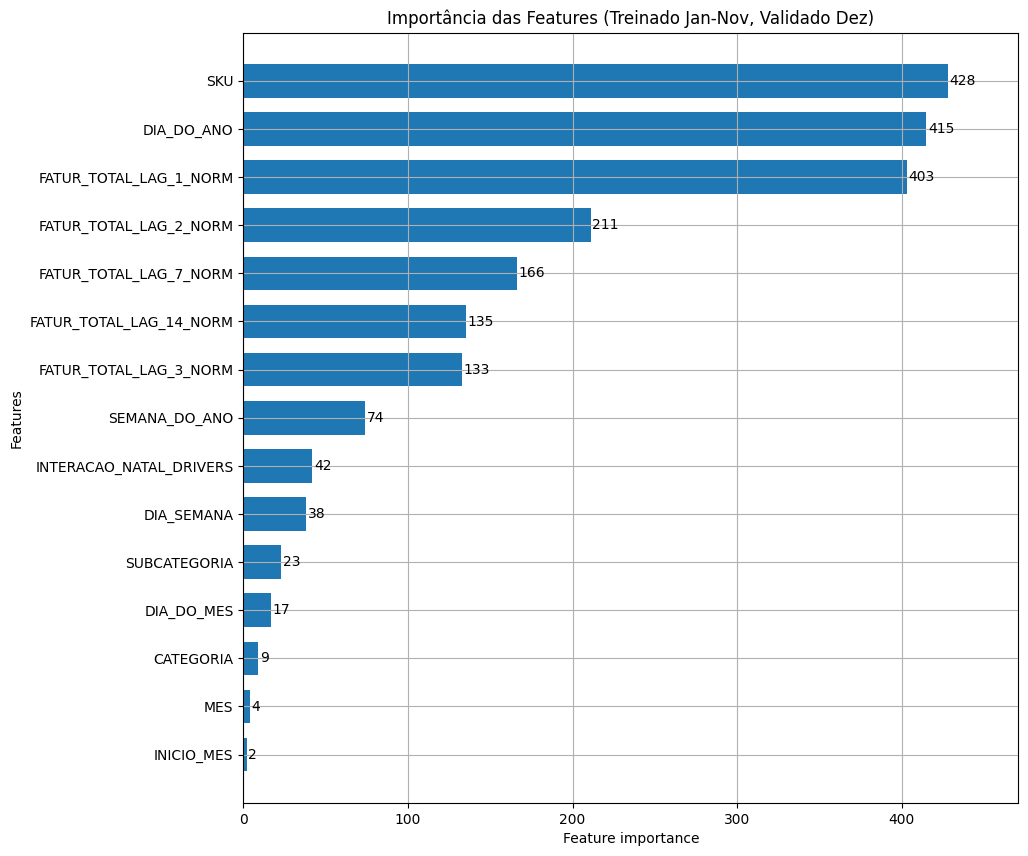

In [33]:
print("Plotando a importância das features (do último Fold)...")

# Plotar a importância das features
# Usamos 'model_cv', que foi o nome do modelo dentro do loop
lgb.plot_importance(model_cv, figsize=(10, 10), max_num_features=25, height=0.7)
plt.title("Importância das Features (Treinado Jan-Nov, Validado Dez)")
plt.show()

### **7. Análise de Erros (Foco no SKU 1813)**

Visão Geral: Esta etapa é crucial para responder diretamente à Pergunta 2 do case. Consolida os resultados de todos os 3 folds de validação, foca-se no SKU 1813 e calcula o erro médio e percentual deste produto específico em diferentes períodos do ano.

Analisando performance específica para o SKU 1813 (em todos os Folds)...

--- Análise SKU 1813 (Todos os períodos de Validação) ---
Faturamento Médio Real (SKU 1813): R$ 2,119.93
MAE Específico (SKU 1813):         R$ 1,108.75
Erro Percentual (SKU 1813):       52.30%


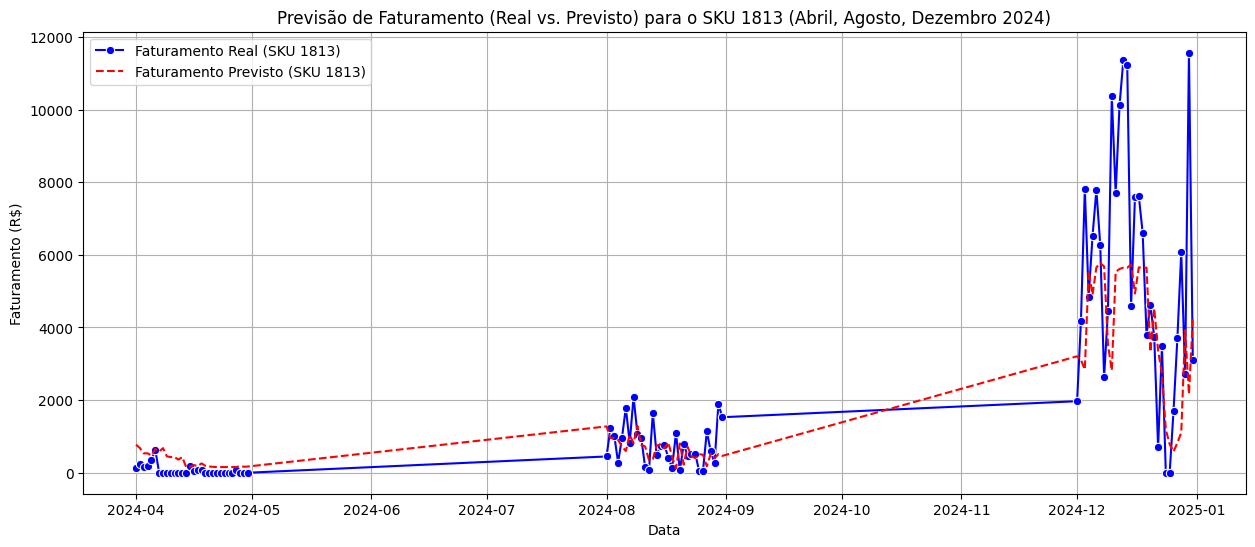

In [34]:
print("Analisando performance específica para o SKU 1813 (em todos os Folds)...")

# Concatena os resultados de todos os folds em um único DataFrame
df_all_results = pd.concat(all_fold_results)

# Filtra para o SKU 1813
df_sku_1813 = df_all_results[df_all_results['SKU'] == 1813].copy()
df_sku_1813['DATA_ATEND'] = pd.to_datetime(df_sku_1813['DATA_ATEND'])

# Calcula o MAE específico
sku_1813_mae = mean_absolute_error(df_sku_1813[TARGET], df_sku_1813['Previsto'])
sku_1813_fatur_medio = df_sku_1813[TARGET].mean()

print(f"\n--- Análise SKU 1813 (Todos os períodos de Validação) ---")
print(f"Faturamento Médio Real (SKU 1813): R$ {sku_1813_fatur_medio:,.2f}")
print(f"MAE Específico (SKU 1813):         R$ {sku_1813_mae:,.2f}")

# Evita divisão por zero
if sku_1813_fatur_medio > 0:
    print(f"Erro Percentual (SKU 1813):       {sku_1813_mae / sku_1813_fatur_medio * 100:,.2f}%")
else:
    print("SKU 1813 não teve faturamento no período de validação.")


# Plotar a série temporal Real vs. Previsto para o SKU 1813
if not df_sku_1813.empty:
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=df_sku_1813, x='DATA_ATEND', y=TARGET, label='Faturamento Real (SKU 1813)', color='blue', marker='o')
    sns.lineplot(data=df_sku_1813, x='DATA_ATEND', y='Previsto', label='Faturamento Previsto (SKU 1813)', color='red', linestyle='--')
    plt.title('Previsão de Faturamento (Real vs. Previsto) para o SKU 1813 (Abril, Agosto, Dezembro 2024)')
    plt.ylabel('Faturamento (R$)')
    plt.xlabel('Data')
    plt.legend()
    plt.grid(True)
    plt.show()

### **8. Impressão dos Resultados Finais (Consolidação)**

Visão Geral: Esta etapa consolida os resultados do Cross-Validation e a análise de erros. A seção 1 imprime as métricas médias de RMSE e MAE (do loop da Etapa 5). A seção 2 imprime a tabela de features e, finalmente, a seção 3 imprime a análise detalhada do SKU 1813 (do dataframe consolidado da Etapa 7), fornecendo todas as informações necessárias para as conclusões do case.

In [35]:
# --- 1. MÉTRICAS GLOBAIS (Média de todos os Folds) ---
print("\n" + "="*70)
print("--- 1. MÉTRICAS MÉDIAS DE PERFORMANCE (Cross-Validation) ---")
print(f"RMSE Médio: R$ {mean_rmse:,.2f} (± R$ {std_rmse:,.2f})")
print(f"MAE Médio:  R$ {mean_mae:,.2f} (± R$ {std_mae:,.2f})")
print(f"\nConclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ {mean_mae:,.2f}.")
print("="*70)

# --- 2. IMPORTÂNCIA DAS FEATURES (Do último modelo) ---
print("\n--- 2. IMPORTÂNCIA DAS FEATURES (Último Modelo - Fold 3) ---")
# Usamos o model_cv e feature_name_ do último fold da Etapa 4
df_importancia = pd.DataFrame({
    'feature': model_cv.feature_name_,       
    'importance': model_cv.feature_importances_  
}).sort_values(by='importance', ascending=False)
print(df_importancia.to_string())
print("-" * 70)


# --- 3. ANÁLISE DE ERROS (FOCO SKU 1813) ---
print("\n--- 3. ANÁLISE ESPECÍFICA DO SKU 1813 (Todos os períodos de Validação) ---")

# Filtrando o dataframe que foi gerado na Etapa 7 (df_all_results)
df_sku_1813 = df_all_results[df_all_results['SKU'] == 1813].copy()
sku_1813_fatur_medio = df_sku_1813[TARGET].mean()
sku_1813_mae = mean_absolute_error(df_sku_1813[TARGET], df_sku_1813['Previsto'])

print(f"Faturamento Médio Real (SKU 1813): R$ {sku_1813_fatur_medio:,.2f}")
print(f"MAE Específico (SKU 1813):         R$ {sku_1813_mae:,.2f}")

# Evita divisão por zero
if sku_1813_fatur_medio > 0:
    print(f"Erro Percentual (SKU 1813):       {sku_1813_mae / sku_1813_fatur_medio * 100:,.2f}%")
else:
    print("SKU 1813 não teve faturamento no período de validação.")

# Imprime o detalhe diário (limitado para legibilidade)
print("\n--- Detalhe Diário SKU 1813 (Real vs. Previsto) ---")
df_sku_1813_debug = df_sku_1813[['DATA_ATEND', TARGET, 'Previsto', 'FATUR_TOTAL_LAG_1_NORM', 'INTERACAO_NATAL_DRIVERS', 'INTERACAO_ANO_NOVO_DRIVERS']].copy()

print(df_sku_1813_debug.to_string(float_format='%.2f'))
print("-" * 70)


--- 1. MÉTRICAS MÉDIAS DE PERFORMANCE (Cross-Validation) ---
RMSE Médio: R$ 545.01 (± R$ 458.60)
MAE Médio:  R$ 227.92 (± R$ 142.95)

Conclusão: O nosso modelo, em média, erra a previsão de faturamento do SKU em R$ 227.92.

--- 2. IMPORTÂNCIA DAS FEATURES (Último Modelo - Fold 3) ---
                       feature  importance
0                          SKU         428
5                   DIA_DO_ANO         415
18      FATUR_TOTAL_LAG_1_NORM         403
19      FATUR_TOTAL_LAG_2_NORM         211
21      FATUR_TOTAL_LAG_7_NORM         166
22     FATUR_TOTAL_LAG_14_NORM         135
20      FATUR_TOTAL_LAG_3_NORM         133
7                SEMANA_DO_ANO          74
16     INTERACAO_NATAL_DRIVERS          42
3                   DIA_SEMANA          38
2                 SUBCATEGORIA          23
4                   DIA_DO_MES          17
1                    CATEGORIA           9
6                          MES           4
9                   INICIO_MES           2
17  INTERACAO_ANO_NOVO_DRI